# 05 — Baseline Modeling (optional extension)

**Question:** Can basic weather on the discovery day predict how large a fire becomes?

**Target:** `log_fire_size` = log(1 + acres). We predict the log because raw acres are so skewed that a model would
spend all its effort on a handful of giant fires.

**Features (inputs):** max temperature, humidity, wind speed, rain that day, rain in the prior 7 days, and month.

**Plan:**
1. Split the data into a **training set** (80%) the model learns from and a **test set** (20%) it has never seen.
2. Build a **baseline** that ignores weather and always predicts the average. Any real model must beat this.
3. Fit **Linear Regression** (simple, easy to interpret).
4. Fit a **Random Forest** (can capture non-linear patterns and interactions).
5. Compare them on the test set.

The goal is to show **correct methodology**, not to chase a high score.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sys.path.append("../src")
from visualization import set_chart_style, save_figure, BLUE

set_chart_style()
wildfires = pd.read_csv("../data/processed/wildfires_with_weather.csv", parse_dates=["discovery_date"])

feature_columns = ["temp_max_f", "relative_humidity", "wind_speed_mph",
                   "precip_mm", "precip_prev_7day_mm", "fire_month"]
target_column = "log_fire_size"

model_data = wildfires.dropna(subset=feature_columns + [target_column])
X = model_data[feature_columns]
y = model_data[target_column]
print("Rows available for modeling:", len(model_data))

Rows available for modeling: 251880


## 1. Train/test split
`random_state=42` makes the random split the same every time the notebook runs, so results are reproducible.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train))
print("Test rows:    ", len(X_test))

Training rows: 201504
Test rows:     50376


## 2. Evaluation metrics
All errors are in **log units** (log of 1 + acres).
- **MAE (Mean Absolute Error):** the average size of the prediction error. Lower is better.
- **RMSE (Root Mean Squared Error):** like MAE but punishes big misses more. Lower is better.
- **R² (R-squared):** the share of the variation in fire size the model explains, compared with always predicting
  the average. 1.0 = perfect, 0 = no better than the average, below 0 = worse than the average.

In [3]:
def evaluate(model_name, y_true, y_predicted):
    """Return the three metrics for one model as a dictionary."""
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_predicted),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_predicted))),
        "R2": r2_score(y_true, y_predicted),
    }

## 3. Baseline: always predict the average

In [4]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
results = [evaluate("Baseline (predict average)", y_test, baseline.predict(X_test))]
results[-1]

{'model': 'Baseline (predict average)',
 'MAE': 0.6706343466921604,
 'RMSE': 1.1337790065381426,
 'R2': -0.00014070293601609052}

## 4. Linear Regression

In [5]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_test, linear_model.predict(X_test)))
results[-1]

{'model': 'Linear Regression',
 'MAE': 0.6661592811190019,
 'RMSE': 1.1228885360310208,
 'R2': 0.01898064506797048}

**Coefficients:** how much the predicted log fire size changes when a feature increases by one unit,
*holding the other features fixed*. Treat these as descriptions of the fitted line, not as causal effects.
Month is treated as a number (1–12) here, which is a simplification: it assumes December is "more" than January.

In [6]:
pd.DataFrame({"feature": feature_columns, "coefficient": linear_model.coef_}).round(4)

,feature,coefficient
0,temp_max_f,0.0058
1,relative_humidity,-0.0037
2,wind_speed_mph,0.0301
3,precip_mm,-0.0027
4,precip_prev_7day_mm,-0.0009
5,fire_month,0.0012


## 5. Random Forest

A random forest builds many **decision trees**, each on a random sample of the training data, and averages their
predictions. It can learn curved relationships and interactions (e.g. "hot *and* dry") that a straight line can't.

Settings: 100 trees; `max_depth=12` and `min_samples_leaf=50` stop trees from memorizing the training data
(overfitting). `n_jobs=-1` uses all CPU cores. Training takes a minute or two.

In [7]:
forest = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=50,
                               n_jobs=-1, random_state=42)
forest.fit(X_train, y_train)
results.append(evaluate("Random Forest", y_test, forest.predict(X_test)))
results[-1]

{'model': 'Random Forest',
 'MAE': 0.6604581453750139,
 'RMSE': 1.1137614261893953,
 'R2': 0.03486375635806094}

### Checking for overfitting: training score vs. test score

In [8]:
print("Random Forest R2 on training data:", round(r2_score(y_train, forest.predict(X_train)), 3))
print("Random Forest R2 on test data:    ", round(r2_score(y_test, forest.predict(X_test)), 3))

Random Forest R2 on training data: 0.064
Random Forest R2 on test data:     0.035


If the training score were much higher than the test score, the model would be memorizing rather than learning.

## 6. Comparison

In [9]:
comparison = pd.DataFrame(results).set_index("model").round(3)
comparison.to_csv("../results/model_comparison.csv")
comparison

,MAE,RMSE,R2
model,,,
Baseline (predict average),0.671,1.134,-0.000
Linear Regression,0.666,1.123,0.019
Random Forest,0.660,1.114,0.035


**Interpretation (random split):** both models beat the baseline, but only slightly. The Random Forest explains
about **3.5%** of the variation in log fire size (R² ≈ 0.035) and Linear Regression about **1.9%**.
The forest's small edge suggests some non-linear patterns or interactions exist, but weather on the discovery day
leaves about 96% of the variation unexplained.

## 7. A tougher test: train on the past, predict the future

A random split mixes years together, so fires from the same day and place (which share identical weather) can land
in both the training and test sets. That can make results look better than they really are.
A stricter test trains on **1992–2014** and tests on **2015–2020**.

In [10]:
train_years = model_data["fire_year"] <= 2014
X_past, y_past = X[train_years], y[train_years]
X_future, y_future = X[~train_years], y[~train_years]
print("Train (1992-2014):", len(X_past), "  Test (2015-2020):", len(X_future))

time_results = []
for name, model in [
    ("Baseline (predict average)", DummyRegressor(strategy="mean")),
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=50,
                                            n_jobs=-1, random_state=42)),
]:
    model.fit(X_past, y_past)
    time_results.append(evaluate(name, y_future, model.predict(X_future)))

time_comparison = pd.DataFrame(time_results).set_index("model").round(3)
time_comparison.to_csv("../results/model_comparison_time_split.csv")
time_comparison

Train (1992-2014): 200967   Test (2015-2020): 50913


,MAE,RMSE,R2
model,,,
Baseline (predict average),0.695,1.170,-0.007
Linear Regression,0.700,1.166,-0.000
Random Forest,0.698,1.165,0.002


**Interpretation (time split):** when predicting 2015–2020 from 1992–2014, neither model beats the baseline
in any meaningful way (R² ≈ 0). The small gains from the random split did **not** carry over to new years.
Possible reasons: reporting practices changed (e.g. median recorded size shifted to 0.1 acres after 2014),
and 2015–2020 included unusually extreme fire seasons. This is exactly why testing on "future" data matters.

**Interpretation (random split):** both models beat the baseline, but only slightly. The Random Forest explains
about **3.5%** of the variation in log fire size (R² ≈ 0.035) and Linear Regression about **1.9%**.
The forest's small edge suggests some non-linear patterns or interactions exist, but weather on the discovery day
leaves about 96% of the variation unexplained.

## 8. Feature importance (Random Forest)

Feature importance shows how much each input helped the forest reduce prediction error, summed over all trees.

**Important caveats:**
- Importance does **not** mean a variable *causes* larger fires. It only means the model found it useful for
  prediction.
- This built-in measure tends to favor variables with many distinct values (like temperature) over ones with few
  (like month), and it splits credit between correlated variables (temperature and humidity).

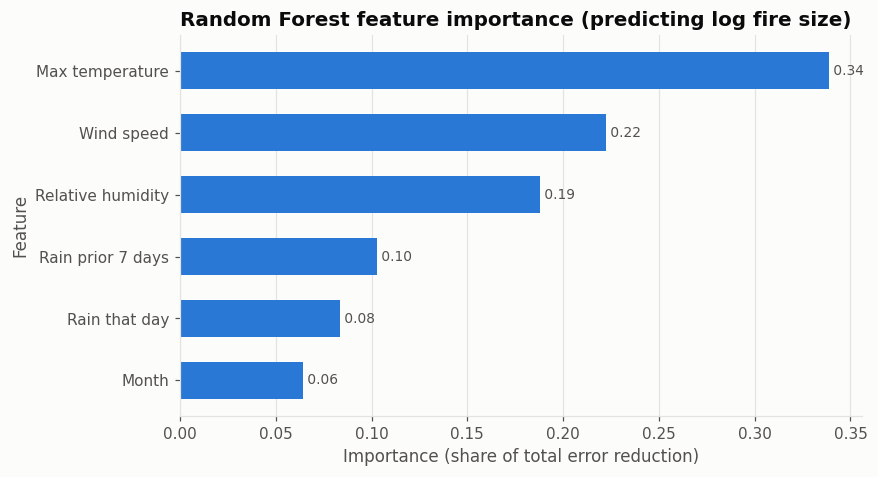

temp_max_f             0.339
wind_speed_mph         0.222
relative_humidity      0.188
precip_prev_7day_mm    0.103
precip_mm              0.083
fire_month             0.064
dtype: float64

In [11]:
importance = pd.Series(forest.feature_importances_, index=feature_columns).sort_values()
readable_names = {
    "temp_max_f": "Max temperature", "relative_humidity": "Relative humidity",
    "wind_speed_mph": "Wind speed", "precip_mm": "Rain that day",
    "precip_prev_7day_mm": "Rain prior 7 days", "fire_month": "Month",
}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([readable_names[name] for name in importance.index], importance.values, color=BLUE, height=0.6)
for position, value in enumerate(importance.values):
    ax.text(value, position, f" {value:.2f}", va="center", fontsize=9, color="#52514e")
ax.set_title("Random Forest feature importance (predicting log fire size)")
ax.set_xlabel("Importance (share of total error reduction)")
ax.set_ylabel("Feature")
ax.grid(axis="y", visible=False)
save_figure(fig, "12_feature_importance.png")
plt.show()
importance.sort_values(ascending=False).round(3)

## 9. Why weather alone predicts fire size poorly

The key things that decide how big a fire gets are **not in this dataset**:
- **Fuel:** vegetation type, how much has built up, and how dry it is (live fuel moisture)
- **Terrain:** slope and elevation; fires run uphill quickly
- **Suppression:** how fast crews arrive, access roads, available resources
- **Weather after discovery:** a fire can burn for weeks; we only use the first day
- **Local weather:** our weather is a ~55 km grid-cell daily average, missing afternoon extremes and gusts
- **Ignition location:** a roadside fire near a fire station vs. one in remote wilderness

Also, most records are tiny fires whose size is rounded (0.1 or 1 acre), which adds noise to the target.
A low R² here is an honest and expected result, not a failure of the method.